$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\yv}{\mathbf{y}}
\providecommand{\zv}{\mathbf{z}}
$$

## Problem 1: Lagrange multipliers

Solve the constrained optimization problem

$$\min_{(x, y) \in \R^2}\ x + 2y \quad \text{s.t.} \quad x^2 + 4 y^2 = 4$$

by Lagrange multipliers.

**Solution.**

We know that at a minimum $(x^\ast,y^\ast)$ the contour lines of the objective function $f$ and the equality constraint $g$ touch and thus it needs to hold that

$$\nabla f(x^\ast,y^\ast) = \lambda \nabla g(x^\ast,y^\ast)$$

for some Lagrange multiplier $\lambda \in \R$.

Hence, we get the two equalities

$$\begin{aligned} 1 &= \lambda 2 x^\ast \\ 2 &= \lambda 8 y^\ast \end{aligned}$$

yielding $x^\ast = 2 y^\ast$.

The third equality is the equality constraint. It gives

$$\begin{aligned} {x^\ast}^2 + 4{y^\ast}^2 &= 4 \\ \Leftrightarrow \quad 4 {y^\ast}^2 + 4{y^\ast}^2 &= 4 \\ \Leftrightarrow \quad 8 {y^\ast}^2 &= 4 \\ \Leftrightarrow \quad {y^\ast}^2 &= \frac{1}{2}. \end{aligned}$$

Therefore, we have two candidate solutions

$$(x^\ast_1,y^\ast_1) = (\sqrt{2},1/\sqrt{2}) \quad \text{or} \quad (x^\ast_2,y^\ast_2) = (-\sqrt{2},-1/\sqrt{2}).$$

Since $f(x^\ast_1, y^\ast_1) > f(x^\ast_2,y^\ast_2)$, we get the solution

$$(x^\ast,y^\ast) = (-\sqrt{2},-1/\sqrt{2}).$$

## Problem 2: Nonlinear SVM

We have $200$ binary observations from a *moons* distribution (two interleaved half-circles) — not linearly separable. The standard SVM trick: lift to a higher-dimensional feature space via $\phi: \R^d \to \R^l$ and learn a linear separator there. The primal soft-margin SVM in feature space is

$$\min_{\bm{\theta}, \theta_0, \bm{\zeta}}\ \tfrac{1}{2}\|\bm{\theta}\|^2 + C\sum_{i=1}^n \zeta^{(i)} \quad \text{s.t.} \quad y^{(i)}\!\left(\langle \bm{\theta}, \phi(\xv^{(i)})\rangle + \theta_0\right) \geq 1 - \zeta^{(i)},\ \zeta^{(i)} \geq 0\ \forall i.$$

Warning message:
"package 'CVXR' was built under R version 4.4.3"



Attaching package: 'CVXR'




The following objects are masked from 'package:stats':

    power, sd, var




The following objects are masked from 'package:base':

    diag, norm, outer




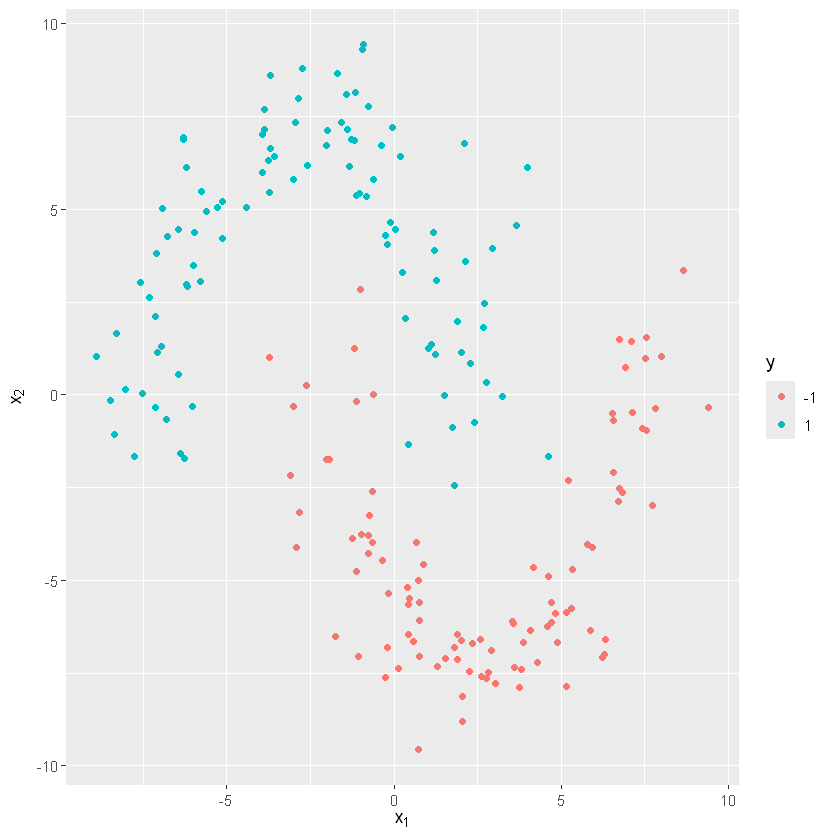

In [1]:
#| label: setup_data
library(ggplot2)
library(CVXR)

# 200 nonlinearly separable observations from a moons distribution.
moon_data <- read.csv("data/moons.csv")
n <- nrow(moon_data)
moon_data$y_dec <- as.factor(moon_data$y)

ggplot(moon_data, aes(x = x1, y = x2, color = y_dec)) +
  geom_point(size = 1.5) +
  xlab(expression(x[1])) + ylab(expression(x[2])) +
  labs(color = expression(y))

### (a) Lagrangian

Write down the Lagrangian of the nonlinear SVM.

**Solution.**

$$\mathcal{L} = 0.5\Vert \bm{\theta} \Vert^2 + C\sum^n_{i=1}\zeta^{(i)} - \sum^n_{i=1}\alpha^{(i)}(\mathbf{y}^{(i)}({\phi(\mathbf{x}^{(i)})}^\top\bm{\theta} + \theta_0) - 1 + \zeta^{(i)})- \sum^n_{i=1}\mu^{(i)}\zeta^{(i)}$$

### (b) Solve the primal SVM

Solve the primal nonlinear SVM with $C = 1$ and a third-order polynomial transformation (without intercept)

$$\phi(\xv) = (x_1, x_2, x_1^2, x_2^2, x_1 x_2, x_1^2 x_2, x_1 x_2^2, x_1^3, x_2^3)^\top \in \R^9$$

using `CVXR` (R) or `cvxpy` (Python).

ℹ In a future CVXR release, `solve()` will return the optimal value directly
  (like `psolve()`).
ℹ The `$getValue()`/`$getDualValue()` interface will be removed.
ℹ New API: `psolve(prob)`, then `value(x)`, `dual_value(constr)`,
  `status(prob)`.
This message is displayed once per session.


Warning message:
"`getValue()` is deprecated.
ℹ Use `value(x)` after solving instead.
This warning is displayed once per session."


primal: status = optimal, obj = 0.4163, theta_0 = -0.1928


theta = ( +0.839, -0.295, +0.074, +0.062, +0.102, +0.013, +0.061, -0.076, +0.111 )


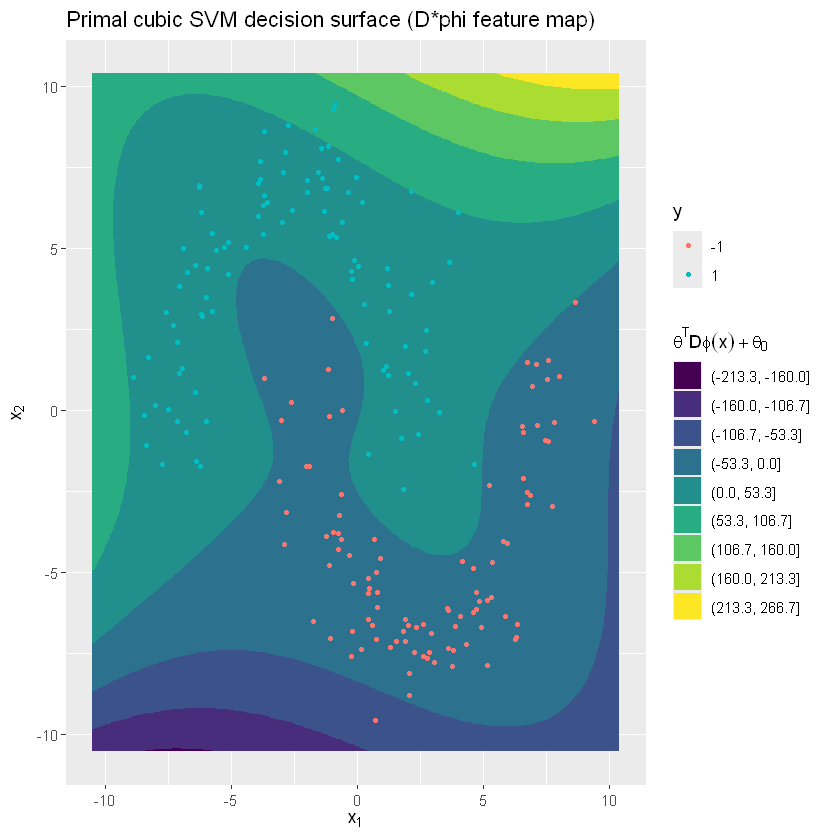

In [2]:
#| label: solution_2b_code
X <- as.matrix(moon_data[, c("x1", "x2")])

# Cubic polynomial transformation (without intercept), 9 features
cubic <- function(x) cbind(x[, 1], x[, 2],
                           x[, 1]^2, x[, 2]^2, x[, 1] * x[, 2],
                           x[, 1]^2 * x[, 2], x[, 1] * x[, 2]^2,
                           x[, 1]^3, x[, 2]^3)

# Diagonal scaling so that <D phi(x), D phi(z)> = (x^T z + 1)^3 - 1
# (matches the dual kernel in (e)).
D_diag <- c(sqrt(3), sqrt(3), sqrt(3), sqrt(3), sqrt(6), sqrt(3), sqrt(3), 1, 1)
D <- diag(D_diag)

Z   <- cubic(X)              # raw phi(X); used in (e) when recovering theta
Z_D <- Z %*% D               # D*phi(X); used in the primal constraint below
C_val <- 1.0

theta0 <- Variable()
theta  <- Variable(9)
slack  <- Variable(n)

obj <- (1/2) * sum_squares(theta) + C_val * sum(slack)
constr <- list(
  moon_data$y * (Z_D %*% theta + theta0) >= 1 - slack,
  slack >= 0
)
prob <- Problem(Minimize(obj), constr)
solution <- solve(prob)

theta0_p <- as.numeric(solution$getValue(theta0))
theta_p  <- as.numeric(solution$getValue(theta))   # theta in D*phi basis
cat(sprintf("primal: status = %s, obj = %.4f, theta_0 = %+.4f\n",
            solution$status, solution$value, theta0_p))
cat("theta = (", paste(sprintf("%+.3f", theta_p), collapse = ", "), ")\n")

# Decision boundary on a grid spanning the data (range computed dynamically).
x_lim <- range(moon_data$x1, moon_data$x2)
pad <- 0.05 * diff(x_lim)
x_grid <- seq(x_lim[1] - pad, x_lim[2] + pad, length.out = 120)
g <- expand.grid(x1 = x_grid, x2 = x_grid)
y_g <- as.numeric(cubic(as.matrix(g)) %*% D %*% theta_p) + theta0_p
df_g <- data.frame(g, val = y_g)

ggplot() +
  geom_contour_filled(data = df_g, aes(x1, x2, z = val), bins = 10) +
  geom_point(data = moon_data, aes(x1, x2, color = y_dec), size = 1.2) +
  xlab(expression(x[1])) + ylab(expression(x[2])) +
  labs(color = expression(y),
       fill = expression(theta^T * D * phi(x) + theta[0])) +
  ggtitle("Primal cubic SVM decision surface (D*phi feature map)")

### (c) KKT conditions

State the KKT conditions of the general nonlinear SVM.

**Solution.**

Stationarity

$$\nabla_{\bm{\theta}}\mathcal{L} = \bm{\theta} - \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}) = 0$$
$$\nabla_{\theta_0}\mathcal{L} = - \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)} = 0$$
$$\nabla_{\bm{\zeta}}\mathcal{L} = C\cdot\mathbf{1}_n - \alpha - \mu = 0$$

Primal feasability

$$-(\mathbf{y}^{(i)}({\phi(\mathbf{x}^{(i)})}^\top\bm{\theta} + \theta_0) - 1 + \zeta^{(i)}) \leq 0$$
$$- \zeta^{(i)} \leq 0$$

Dual feasability

$$\mu \geq 0$$
$$\alpha \geq 0$$

Complementary slackness

$$-\mu^{(i)}\zeta^{(i)} = 0 \quad i = 1,\dots,n$$
$$-\alpha^{(i)}(\mathbf{y}^{(i)}({\phi(\mathbf{x}^{(i)})}^\top\bm{\theta} + \theta_0) - 1 + \zeta^{(i)}) = 0 \quad i = 1,\dots, n$$

### (d) Dual form

Derive the dual form of the nonlinear SVM. State an advantage of the dual over the primal.

*Hint:* use the KKT conditions to eliminate the primal variables from the Lagrangian.

**Solution.**

From the KKT conditions it follows that $$\bm{\theta} = \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}),$$
$$\sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)} = 0,$$
$$C  - \underbrace{\mu^{(i)}}_{\geq 0} = \alpha^{(i)}  \Rightarrow C \geq \alpha^{(i)} \quad i=1,\dots,n. $$
Plugging these into the Lagrangian gives

$$0.5\Vert  \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}) \Vert^2 + \sum^n_{i=1}\mu^{(i)}\zeta^{(i)} + \sum^n_{i=1}\alpha^{(i)}\zeta^{(i)} - \Vert  \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}) \Vert^2  + \sum^n_{i=1}\alpha^{(i)} - \sum^n_{i=1}\alpha^{(i)}\zeta^{(i)})- \sum^n_{i=1}\mu^{(i)}\zeta^{(i)}$$
$$= -0.5\Vert  \sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)}\phi(\mathbf{x}^{(i)}) \Vert^2  + \sum^n_{i=1}\alpha^{(i)} =  -0.5  \sum^n_{i=1}\sum^n_{j=1}\alpha^{(i)}\alpha^{(j)}\mathbf{y}^{(i)}\mathbf{y}^{(j)} \langle\phi(\mathbf{x}^{(i)}),\phi(\mathbf{x}^{(j)})\rangle   + \sum^n_{i=1}\alpha^{(i)}$$

Hence, the dual form of the nonlinear SVM is

$$\max_{\alpha}  -0.5  \sum^n_{i=1}\sum^n_{j=1}\alpha^{(i)}\alpha^{(j)}\mathbf{y}^{(i)}\mathbf{y}^{(j)} \langle\phi(\mathbf{x}^{(i)}),\phi(\mathbf{x}^{(j)})\rangle   + \sum^n_{i=1}\alpha^{(i)}$$

s.t.

$$\sum^n_{i=1}\alpha^{(i)}\mathbf{y}^{(i)} = 0,$$
$$0 \leq \alpha \leq C.$$

Here, we can use the kernel trick to evaluate $\langle\phi(\mathbf{x}^{(i)}),\phi(\mathbf{x}^{(j)})\rangle$ without explicitly computing the projections of each observation. (We only need to compute  $\langle\mathbf{x}^{(i)},\mathbf{x}^{(j)}\rangle$)

### (e) Solve the dual SVM

Solve the dual form from (b) via `CVXR`/`cvxpy`.

*Hint 1:* For a polynomial transformation $\phi$ of order $l$ (without intercept) there exists an invertible diagonal $\mathbf{D} \in \R^{l \times l}$ such that $\langle \mathbf{D}\phi(\xv), \mathbf{D}\phi(\zv)\rangle = (\xv^\top \zv + 1)^l - 1$.

*Hint 2:* Add $10^{-7} \mathbf{I}$ to the kernel matrix to ensure invertibility / positive-definiteness.

dual:   status = optimal, obj = 0.4163


recovered: theta_0 = -0.1928, primal/dual obj diff = 7.0105e-09


support vectors: 10 / 200 (alpha_i > 1e-04)


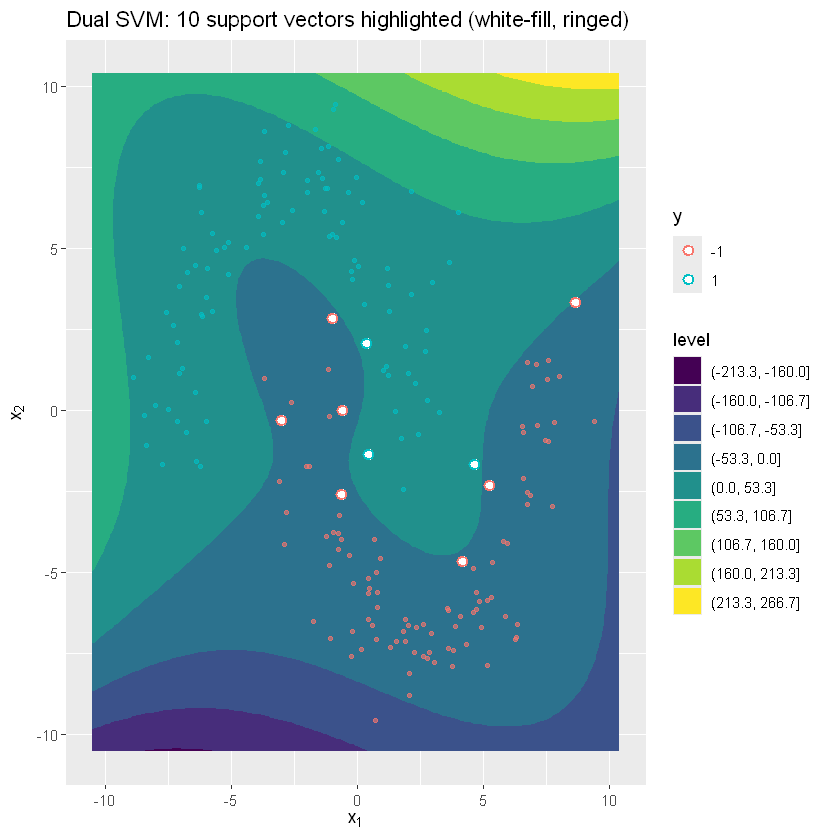

In [3]:
#| label: solution_2e_code
# Kernel matrix: K = (X X^T + 1)^3 - 1.
# Hint 1: <D phi(x), D phi(z)> = (x^T z + 1)^l - 1
K <- (X %*% t(X) + 1)^3 - 1
P <- diag(moon_data$y) %*% K %*% diag(moon_data$y)
P <- P + diag(n) * 1e-7                                  # Hint 2: ensure PD

alpha <- Variable(n)
obj_d <- sum(alpha) - (1/2) * quad_form(alpha, P)
constr_d <- list(t(alpha) %*% moon_data$y == 0,
                 alpha >= 0,
                 alpha <= C_val)
prob_d <- Problem(Maximize(obj_d), constr_d)
solution_d <- solve(prob_d)
alpha_p <- as.numeric(solution_d$getValue(alpha))
cat(sprintf("dual:   status = %s, obj = %.4f\n",
            solution_d$status, solution_d$value))

# Recover theta via the diagonal scaling D so that <D phi, D phi> = K
D <- diag(c(rep(sqrt(3), 4), sqrt(6), rep(sqrt(3), 2), 1, 1))
theta_d <- as.numeric(t(alpha_p * moon_data$y) %*% Z %*% D)

# theta_0: midpoint between max negative and min positive class scores
scores <- as.numeric(Z %*% D %*% theta_d)
theta0_d <- -0.5 * (max(scores[moon_data$y == -1]) +
                    min(scores[moon_data$y == 1]))
cat(sprintf("recovered: theta_0 = %+.4f, primal/dual obj diff = %.4e\n",
            theta0_d, solution$value - solution_d$value))

# Support vectors: alpha_i > eps
# (active margin constraint, by complementary slackness).
sv_eps <- 1e-4
sv_mask <- alpha_p > sv_eps
cat(sprintf("support vectors: %d / %d (alpha_i > %.0e)\n",
            sum(sv_mask), n, sv_eps))

y_g_d <- as.numeric(cubic(as.matrix(g)) %*% D %*% theta_d + theta0_d)
df_g_d <- data.frame(g, val = y_g_d)
moon_data$is_sv <- sv_mask

ggplot() +
  geom_contour_filled(data = df_g_d, aes(x1, x2, z = val), bins = 10) +
  geom_point(data = moon_data[!sv_mask, ], aes(x1, x2, color = y_dec),
             size = 1.0, alpha = 0.6) +
  geom_point(data = moon_data[sv_mask, ], aes(x1, x2, color = y_dec),
             size = 2.5, shape = 21, fill = "white", stroke = 1.0) +
  xlab(expression(x[1])) + ylab(expression(x[2])) +
  labs(color = expression(y)) +
  ggtitle(sprintf(paste0("Dual SVM: %d support vectors highlighted ",
                         "(white-fill, ringed)"), sum(sv_mask)))